# Generative BIM Carbon Optimisation

### Key Stages of the Pipeline

#### 1. Parametric Input Space (The Generative Engine)

* **What it does:** Simulates computational design tools (such as Grasshopper or Dynamo) by creating $N = 1,000$ unique design variations.
* **Key Inputs:** Geometric dimensions (`num_floors`, `floor_area`), facade parameters (`wwr_south`, `shading_depth`), and material systems (`Mass Timber` vs. `Concrete`).

#### 2. Material Quantity Extraction & Embodied Carbon ($EC$) Engine

* **What it does:** Replicates the link between a BIM model (like Revit) and Life Cycle Assessment (LCA) tools like One Click LCA or EC3.
* **Calculation:** Converts surface areas and volumes into element weights, multiplying them by environmental product declaration (EPD) factors ($\text{kg CO}_2\text{e}/\text{m}^3$):

$$
\text{Embodied Carbon} =
(\text{Volume}*{\text{Structure}} \times \text{ECF}*{\text{Material}})
+
(\text{Volume}*{\text{Glazing}} \times \text{ECF}*{\text{Glass}})
$$

#### 3. Thermal Mass & Solar Radiation ($OC$) Engine

* **What it does:** Simulates building performance software (like EnergyPlus or Cove.tool) to estimate Energy Use Intensity (EUI in $\text{kWh}/\text{m}^2/\text{yr}$).
* **Calculation:** Adjusts baseline energy usage based on trade-offs:


**Net EUI = Base EUI + Solar heat Gain - Louver Benefit - Thermal Mass Benefit**

* **Lifetime OC:** Multiplies $\text{Net EUI} \times \text{Floor Area} \times \text{Grid Carbon Intensity} \times 60\text{ Years}$.

#### 4. Multi-Objective Pareto Optimization

* **What it does:** Filters out inferior designs to highlight **non-dominated solutions**.
* **The Goal:** Finds design options where you cannot reduce initial material carbon ($EC$) further without causing an increase in operational energy ($OC$).

#### 5. Output Selection & BIM Synchronization

* **What it does:** Identifies the minimum total lifetime carbon configuration (`idxmin()`) and extracts its parametric values (`WWR`, `shading_m`, material choice) so they can be written back into native BIM elements for final detailing.

### Why This Pipeline Matters in Real Practice

Without this multi-objective loop:

* Minimizing **Embodied Carbon** alone yields a lightweight building with poor insulation/shading, driving up HVAC energy.
* Minimizing **Operational Carbon** alone often leads to thick, heavily insulated concrete structures with massive upfront material emissions.

The pipeline ensures both lifecycle phases are balanced during the schematic design stage.


### What This Script Replicates

1. **Generative Loop (Step 1):** Simulates parametric exploration (e.g., Grasshopper/Dynamo mutating geometry parameters).
2. **BIM Material Extraction (Step 2):** Takes element quantities and scales them against localized Environmental Product Declarations (EPDs).
3. **Operational Energy Simulation (Step 3):** Uses heuristic relationships between South Glazing (WWR), shading fins, and thermal mass to compute EUI over a 60-year life.
4. **Pareto Optimization (Step 4 & 5):** Evaluates multi-objective performance, outputting the optimal design points where you cannot decrease initial material carbon without raising operational carbon.


# Example

### Step 1: Initialize Environment & Parametric Input Space

The script begins by setting up a repeatable dataset that acts as our **Parametric Generative Engine** (mimicking Grasshopper, Dynamo, or Revit's Generative Design tool).



1. **What's happening:** Instead of manually modeling 1,000 buildings in CAD, we create 1,000 random combinations of core design variables.
2. **The variables:**
   - **Geometry:** Floor counts ($6$ to $14$), floor plate sizes ($800$ to $1,500\text{ m}^2$).
   - **Facade:** South window ratio ($20\\%$ to $80\\%$), overhang projection ($0$ to $1.5\text{ m}$).
   - **Structure:** $0 = \text{Traditional Concrete}$, $1 = \text{Mass Timber Hybrid}$.
3. **Fixed Constants:** Sets a $60\text{-year}$ building lifecycle and an average electrical grid carbon intensity ($0.25\text{ kg CO}\_2\text{e/kWh}$).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ==============================================================================
# STEP 1: GENERATIVE DESIGN MATRIX (Parametric BIM Variables)
# ==============================================================================

# Set random seed for reproducible generative iterations
np.random.seed(42)   # Step 1

# Generate 1,000 design iterations with varying geometric and material parameters
N_ITERATIONS = 1000  # Step 1

# Parametric Variables
num_floors = np.random.randint(6, 15, size=N_ITERATIONS)          # Floor count
floor_area = np.random.uniform(800, 1500, size=N_ITERATIONS)      # m² per floor
wwr_south = np.random.uniform(0.2, 0.8, size=N_ITERATIONS)        # South Window-to-Wall Ratio
shading_depth = np.random.uniform(0.0, 1.5, size=N_ITERATIONS)    # Outer louver projection (meters)

# Material Choice: 0 = Reinforced Concrete, 1 = Mass Timber Hybrid
structural_material = np.random.choice([0, 1], size=N_ITERATIONS, p=[0.5, 0.5])

# Fixed Constraints
LIFESPAN_YEARS = 60
GRID_CARBON_INTENSITY = 0.25  # kg CO2e / kWh (Average grid intensity)

### Step 2: The Embodied Carbon ($EC$) Calculation Engine

This step simulates the extraction of material quantities from a BIM model and cross-referencing them with Environmental Product Declaration (EPD) databases.

1. **Quantity Takeoff Approximation:**

   * Estimates total floor area and facade surface area using the parametric dimensions.
   * Assumes a baseline structural concrete/timber slab depth ($0.35\text{ m}$) and double-pane glass thickness ($0.02\text{ m}$).
2. **Carbon Factors Applied:**

   * Multiplies calculated structural volume by `110` for Timber or `380` for Concrete.
   * Adds initial emissions caused by glass manufacturing.
3. **Output:** Returns initial upfront Embodied Carbon in metric tonnes ($\text{Tonnes CO}_2\text{e}$).


In [3]:
# ==============================================================================
# STEP 2: EMBODIED CARBON (EC) CALCULATION ENGINE
# ==============================================================================

# Material Embodied Carbon Factors (ECF) in kg CO2e / m3
ECF_CONCRETE = 380.0  # High-carbon traditional structure                       # Step 2
ECF_TIMBER = 110.0    # Mass timber structural system (sequestered net)
ECF_GLASS = 1200.0    # Facade curtain walling system

def calculate_embodied_carbon(floors, area, mat_type, wwr):                     # Step 2
    total_ec = []
    for i in range(len(floors)):
        # Calculate approximate structural volumes based on floor area and count
        total_bldg_area = floors[i] * area[i]
        facade_area = (4 * np.sqrt(area[i])) * (floors[i] * 3.5)
        
        # Volume estimations
        structural_volume = total_bldg_area * 0.35  # Average 0.35m depth slab/column equivalent
        glazing_volume = facade_area * wwr[i] * 0.02  # 20mm glass thickness
        
        # Select Material Factor
        struct_ecf = ECF_TIMBER if mat_type[i] == 1 else ECF_CONCRETE
        
        # Total Initial Embodied Carbon (kg CO2e)
        ec = (structural_volume * struct_ecf) + (glazing_volume * ECF_GLASS)
        total_ec.append(ec / 1e3)  # Convert to Metric Tonnes CO2e
        
    return np.array(total_ec)


### Step 3: The Operational Carbon ($OC$) Simulation Engine

This step acts like a building performance simulation engine (e.g., EnergyPlus or Cove.tool), estimating energy demand over the building's lifespan.

1. **Heuristic Energy Formula:**

   1. Starts with a baseline Energy Use Intensity ($\text{EUI} = 120\text{ kWh/m}^2/\text{year}$).
   2. **Penalty:** Larger south windows (`wwr`) increase cooling loads due to unwanted solar heat gain.
   3. **Benefit:** Deeper external louvers (`shading_depth`) block direct sun, lowering EUI.
   4. **Benefit:** Concrete structures (`mat_type == 0`) offer higher thermal mass, helping regulate interior temperatures slightly better than timber.
2. **Lifetime Calculation:**

   * Computes annual energy use ($\text{Area} \times \text{EUI}$).
   * Multiplies annual energy by grid carbon intensity and scales over $60\text{ years}$ to get total lifetime Operational Carbon.


In [4]:
# ==============================================================================
# STEP 3: OPERATIONAL CARBON (OC) CALCULATION ENGINE
# ==============================================================================
def calculate_operational_carbon(floors, area, wwr, shading, mat_type):          # Step 3
    total_oc = []
    for i in range(len(floors)):
        total_bldg_area = floors[i] * area[i]
        
        # Baseline Energy Use Intensity (EUI in kWh / m² / year)
        base_eui = 120.0                                                         # Step 3
        
        # Penalty: High South WWR increases cooling loads from solar heat gain
        solar_penalty = wwr[i] * 35.0                                            # Step 3
        
        # Benefit: External shading reduces cooling load
        shading_benefit = shading[i] * 12.0                                      # Step 3
        
        # Benefit: Concrete provides thermal mass, lowering peak HVAC demand slightly
        thermal_mass_benefit = 8.0 if mat_type[i] == 0 else 0.0                  # Step 3
        
        # Net Building EUI
        net_eui = base_eui + solar_penalty - shading_benefit - thermal_mass_benefit                          # Step 3
        net_eui = max(net_eui, 60.0)  # Physics floor limit
         
        # Annual Operational Carbon (Tonnes CO2e/year)
        annual_oc = (total_bldg_area * net_eui * GRID_CARBON_INTENSITY) / 1000.0                             # Step 3
        
        # Total Lifetime Operational Carbon over 60 Years
        lifetime_oc = annual_oc * LIFESPAN_YEARS                                                            # Step 3
        total_oc.append(lifetime_oc)
        
    return np.array(total_oc)

In [5]:
# Run calculations
embodied_carbon = calculate_embodied_carbon(num_floors, floor_area, structural_material, wwr_south)
operational_carbon = calculate_operational_carbon(num_floors, floor_area, wwr_south, shading_depth, structural_material)
total_lifetime_carbon = embodied_carbon + operational_carbon

# Combine into pandas DataFrame
df = pd.DataFrame({
    'Floors': num_floors,
    'FloorArea_m2': floor_area,
    'TotalArea_m2': num_floors * floor_area,
    'WWR_South': wwr_south,
    'Shading_m': shading_depth,
    'Material': np.where(structural_material == 1, 'Mass Timber', 'Concrete'),
    'Embodied_CO2e_Tons': embodied_carbon,
    'Operational_CO2e_Tons': operational_carbon,
    'Total_CO2e_Tons': total_lifetime_carbon
})

# Normalize by building footprint to compare intensity (kg CO2e / m²)
df['Carbon_Intensity_kg_m2'] = (df['Total_CO2e_Tons'] * 1000) / df['TotalArea_m2']

### Step 4: Structuring Data & Finding the Pareto Frontier

Now that both $EC$ and $OC$ are calculated for all 1,000 iterations, the script organizes the data and isolates the **Pareto Optimal** candidates.



1. **What is Pareto Dominance?** Design Option A "dominates" Option B if Option A has *both* lower Embodied Carbon AND lower Operational Carbon.
2. **The Function's Logic:** It loops through all iterations and flags designs that cannot be improved in one metric without worsening the other. This subset forms the **Pareto Frontier** (the red dashed line in the plot).

In [6]:
# ==============================================================================
# STEP 4: PARETO FRONTIER IDENTIFICATION
# ==============================================================================
def find_pareto_frontier(ec, oc):
    """Finds non-dominated solutions minimizing both EC and OC simultaneously."""
    data = np.vstack((ec, oc)).T
    is_pareto = np.ones(data.shape[0], dtype=bool)
    for i, c in enumerate(data):
        if is_pareto[i]:
            # Keep points that are not dominated by any other point
            is_pareto[is_pareto] = np.any(data[is_pareto] < c, axis=1) | np.all(data[is_pareto] == c, axis=1)
            is_pareto[i] = True
    return is_pareto

df['Is_Pareto'] = find_pareto_frontier(df['Embodied_CO2e_Tons'].values, df['Operational_CO2e_Tons'].values)

### Step 5: Visualizing Results & Outputting the Optimal BIM Configuration

Finally, the code plots the full search space and extracts the single best design configuration.

1. **Visual Output:** Displays a two-axis scatter plot showing where material choice and facade geometry cluster.
2. **Decision Making:** The design team takes the parametric values from `best_design` (e.g., $8\text{ floors}$, $32% \text{ South WWR}$, $1.35\text{ m}$ shading depth, Mass Timber structure) and locks them back into the main BIM model for technical drawing production.


<Figure size 1000x600 with 0 Axes>

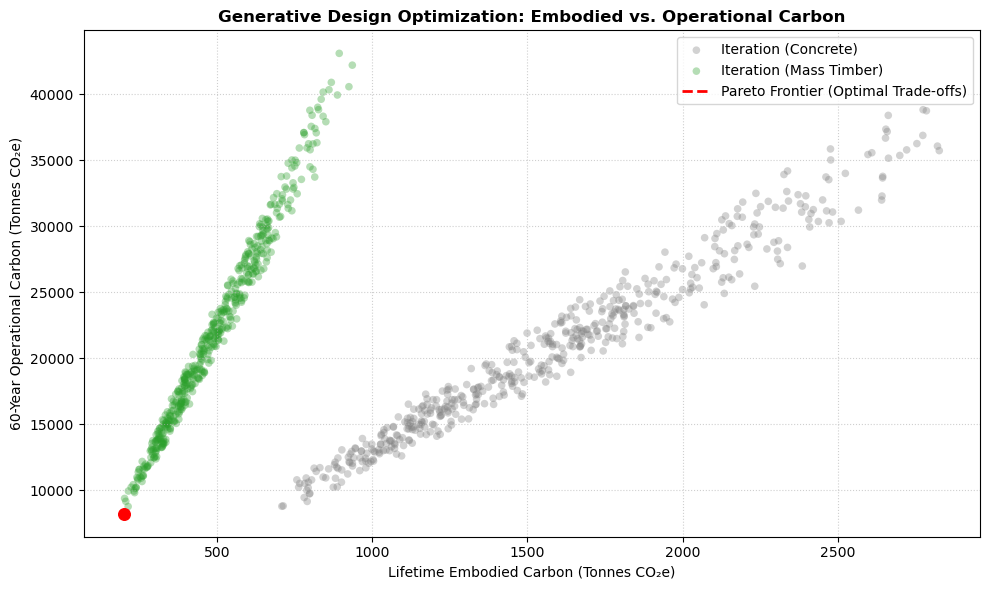

In [7]:
# ==============================================================================
# STEP 5: VISUALIZE GENERATIVE OUTPUTS
# ==============================================================================

plt.figure(figsize=(10, 6), dpi=100)


plt.figure(figsize=(10, 6), dpi=100)

# Scatter all options by material type
for mat, color in zip(['Concrete', 'Mass Timber'], ['#7f7f7f', '#2ca02c']):
    sub = df[df['Material'] == mat]
    plt.scatter(sub['Embodied_CO2e_Tons'], sub['Operational_CO2e_Tons'],                                # Plots Concrete vs Mass Timber dots
                c=color, alpha=0.35, label=f'Iteration ({mat})', edgecolors='none', s=30)

# Plot Pareto Optimal Frontier
pareto_df = df[df['Is_Pareto']].sort_values('Embodied_CO2e_Tons')
plt.plot(pareto_df['Embodied_CO2e_Tons'], pareto_df['Operational_CO2e_Tons'],                          # Draws the red Pareto Frontier curve
         color='red', linestyle='--', linewidth=2, label='Pareto Frontier (Optimal Trade-offs)')
plt.scatter(pareto_df['Embodied_CO2e_Tons'], pareto_df['Operational_CO2e_Tons'], 
            color='red', s=70, zorder=5)

plt.title('Generative Design Optimization: Embodied vs. Operational Carbon', fontsize=12, fontweight='bold')
plt.xlabel('Lifetime Embodied Carbon (Tonnes CO₂e)', fontsize=10)
plt.ylabel('60-Year Operational Carbon (Tonnes CO₂e)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [8]:
# Display Best Option (Lowest total combined carbon)
# Extract single best option based on total combined lifetime carbon

best_design = df.loc[df['Total_CO2e_Tons'].idxmin()]
print("=== OPTIMAL GENERATIVE BIM DESIGN FOUND ===")
print(best_design[['Material', 'Floors', 'TotalArea_m2', 'WWR_South', 'Shading_m', 
                   'Embodied_CO2e_Tons', 'Operational_CO2e_Tons', 'Carbon_Intensity_kg_m2']])

=== OPTIMAL GENERATIVE BIM DESIGN FOUND ===
Material                  Mass Timber
Floors                              6
TotalArea_m2              4824.186374
WWR_South                    0.289278
Shading_m                    1.381961
Embodied_CO2e_Tons         202.267604
Operational_CO2e_Tons     8216.157212
Carbon_Intensity_kg_m2    1745.045519
Name: 603, dtype: object


# How Pareto is decided?  -- Check excel format

### Pareto Optimality and the Rule of Dominance

In multi-objective optimization—such as balancing **Embodied Carbon (EC)** against **Operational Carbon (OC)**—a design is considered **Pareto Optimal** based on the rule of **Dominance**.

#### 1. The Core Rule: "Dominance"

A design option (**Option A**) is said to dominate another design option (**Option B**) if **both** of the following conditions are met:

* **No Worse:** Option A is at least as good as Option B across all objectives.
* **Strictly Better:** Option A is strictly better than Option B in at least one objective.

If Option B is dominated by even one other design in the dataset, it is ruled out as **sub-optimal**.

If no other design in the dataset dominates Option A, then Option A is designated as **Pareto Optimal** (or **non-dominated**).

#### 2. Visual Explanation

Look at **Design A (Blue Dot)** in the chart below:

* **Red Zone (Dominated Region):** Any design landing in this upper-right quadrant relative to Design A is worse in both **Embodied Carbon** AND **Operational Carbon**. Design A easily beats them all.

* **Green Zone (Dominating Region):** If a design lands in this lower-left quadrant, it beats Design A in both metrics. If a point exists here, Design A is no longer Pareto Optimal.

* **White Quadrants (The Trade-Offs):** Points landing in the upper-left or lower-right represent trade-offs (e.g., lower embodied carbon, but higher operational carbon). These designs co-exist with Design A on the **Pareto Frontier** because neither clearly defeats the other.

#### 3. Step-by-Step Numerical Example

Consider three building design iterations:

| Design Option | Embodied Carbon (EC) | Operational Carbon (OC) | Is it Pareto Optimal? | Reason                                                |
| ------------- | -------------------: | ----------------------: | --------------------- | ----------------------------------------------------- |
| **Option 1**  |       $500\text{ t}$ |        $1,800\text{ t}$ | **Sub-optimal**       | Dominated by Option 2 (worse in both metrics).        |
| **Option 2**  |       $400\text{ t}$ |        $1,500\text{ t}$ | **Pareto Optimal**    | No other option has both lower $EC$ and lower $OC$.   |
| **Option 3**  |       $300\text{ t}$ |        $2,000\text{ t}$ | **Pareto Optimal**    | Has lower $EC$ but higher $OC$, creating a trade-off. |


* **Option 2 vs. Option 1:** Option 2 has lower $EC$ ($400$ vs. $500$) **AND** lower $OC$ ($1,500$ vs. $1,800$). Therefore, Option 1 is dominated and discarded.
* **Option 2 vs. Option 3:** Option 3 has lower $EC$ ($300$ vs. $400$), but higher $OC$ ($2,000$ vs. $1,500$). Neither option defeats the other outright, so **both are saved as Pareto Optimal**.

#### 4. How the Algorithm Decides (The Logic Code)

Whether implemented in Python, Excel, or Grasshopper, the program runs a **double-loop comparison** for every candidate design $i$:

The collection of all points where `is_pareto = True` forms the Pareto Frontier curve.

Image generated successfully.


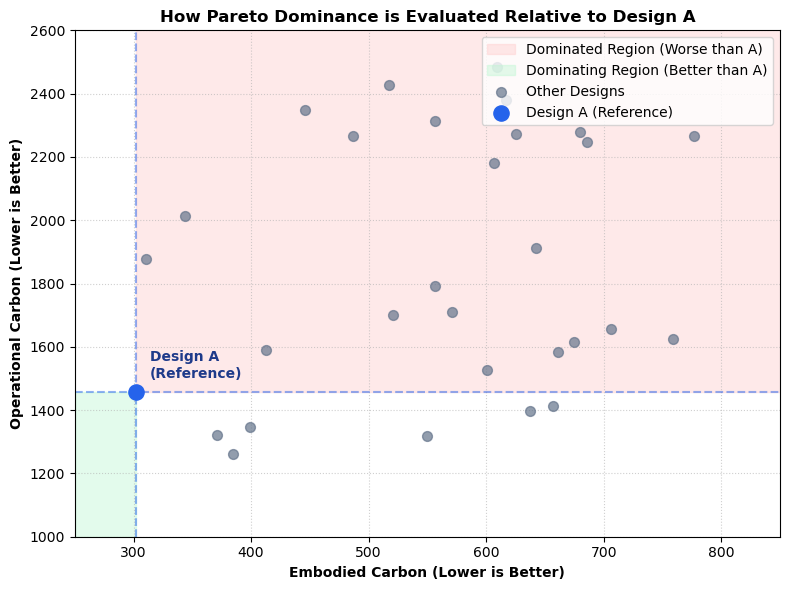

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Create a clear visual explanation of Pareto dominance
np.random.seed(10)
ec = np.random.uniform(300, 800, 30)
oc = np.random.uniform(1200, 2500, 30)

# Select a reference point A
idx_a = 12
a_ec, a_oc = ec[idx_a], oc[idx_a]

# Find points dominated by A (worse in both), points dominating A (better in both), and trade-offs
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Shaded regions from Point A
ax.fill_between([a_ec, 900], a_oc, 2700, color='#fecaca', alpha=0.4, label='Dominated Region (Worse than A)')
ax.fill_between([250, a_ec], 1000, a_oc, color='#bbf7d0', alpha=0.4, label='Dominating Region (Better than A)')

# Plot all points
ax.scatter(ec, oc, color='#64748b', alpha=0.7, s=50, zorder=3, label='Other Designs')

# Highlight Design A
ax.scatter(a_ec, a_oc, color='#2563eb', s=120, zorder=5, label='Design A (Reference)')
ax.annotate('Design A\n(Reference)', (a_ec, a_oc), textcoords="offset points", xytext=(10,10),
            ha='left', fontweight='bold', color='#1e3a8a')

# Dashed lines for Design A thresholds
ax.axvline(a_ec, color='#2563eb', linestyle='--', alpha=0.5)
ax.axhline(a_oc, color='#2563eb', linestyle='--', alpha=0.5)

ax.set_xlim(250, 850)
ax.set_ylim(1000, 2600)
ax.set_xlabel('Embodied Carbon (Lower is Better)', fontweight='bold')
ax.set_ylabel('Operational Carbon (Lower is Better)', fontweight='bold')
ax.set_title('How Pareto Dominance is Evaluated Relative to Design A', fontweight='bold', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show
# plt.savefig('pareto_explanation.png')
print("Image generated successfully.")